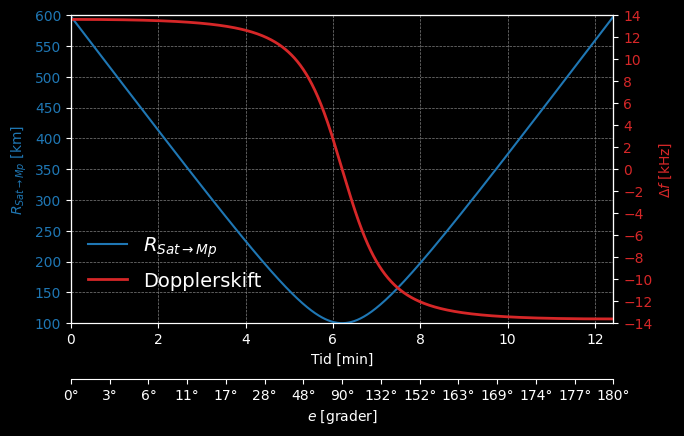

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
plt.style.use('dark_background')

h = 100e3 # km
R_moon = 1737.4e3 # km
a = R_moon + h

m_moon = 7.34767309e22 # kg
G = 6.67430e-11 # m^3 kg^-1 s^-2
T_orbital = 2 * np.pi * np.sqrt((a)**3 / (G * m_moon)) # s
v_orbital = 2 * np.pi * a / T_orbital # m/s

psi_deg = np.linspace(90, 270, 1000) # degrees
psi = np.deg2rad(psi_deg) # rad

theta = np.asin((R_moon/a) * np.sin(psi)) # rad
phi = np.pi - psi - theta

R_sat_meas = a * (np.sin(phi) / np.sin(psi))
R_sat_meas = R_sat_meas * 1e-3 # km

t = (a * (phi + phi[0]) / v_orbital) / 60  # minutter

SAR_freq = 1.25e9 # Hz
c = 3e8 # m/s

doppler = -(2 * SAR_freq * v_orbital / c) * np.sin(psi) * 1e-3 # kHz
 

fig, ax1 = plt.subplots(figsize=(7, 4))

# Første akse: Avstand
ax1.plot(t, R_sat_meas, label=r'$R_{Sat \rightarrow Mp}$', color='tab:blue')
ax1.set_xlabel('Tid [min]')
ax1.set_ylabel(r'$R_{Sat \rightarrow Mp}$ [km]', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_yticks(np.arange(100, 600+1, 50))
ax1.set_ylim(100, 600)
ax1.set_xlim(min(t), max(t))
ax1.grid(linewidth=0.5, linestyle='--', color='gray')
ax1.legend(loc='lower left', fontsize=14, frameon=False, bbox_to_anchor=[0.0, 0.15])

# Andre akse: Doppler
ax2 = ax1.twinx()
ax2.plot(t, doppler, label='Dopplerskift', color='tab:red', linewidth=2)
ax2.set_ylabel(r'$\Delta f$ [kHz]', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.set_yticks(np.arange(-14, 14+0.1, 2))
ax2.set_ylim(-14, 14)
ax2.legend(loc='lower left', fontsize=14, frameon=False, bbox_to_anchor=[0.0, 0.05])

# Tredje akse: Psi under tid
ax3 = ax1.twiny()  # Lager en ekstra x-akse på toppen
ax3.set_xlim(ax1.get_xlim())

e_interp = interp1d(t, psi_deg[::-1]-90, kind='linear', fill_value='extrapolate')
t_ticks = np.linspace(min(t), max(t), 15)
e_ticks = e_interp(t_ticks)

ax3.set_xticks(t_ticks)
ax3.set_xticklabels([f"{e:.0f}°" for e in e_ticks])
ax3.set_xlabel(r'$e$ [grader]')
ax3.xaxis.set_label_position('bottom')
ax3.xaxis.tick_bottom()
ax3.spines['bottom'].set_position(('outward', 40)) # Flytt psi-aksen ned
ax3.spines['bottom'].set_color('white')
ax3.tick_params(axis='x', colors='white')

plt.savefig('Figurer/Synlighetsperiode.pdf', bbox_inches='tight')
plt.show()


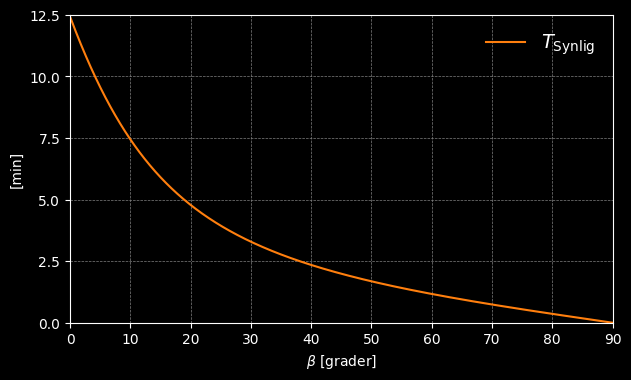

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('dark_background')

# Grunnparametre
h = 100e3 # km
R_moon = 1737.4e3 # km
a = R_moon + h

m_moon = 7.34767309e22 # kg
G = 6.67430e-11 # m^3 kg^-1 s^-2
T_orbital = 2 * np.pi * np.sqrt((a)**3 / (G * m_moon)) # s
v_orbital = 2 * np.pi * a / T_orbital # m/s

# Vinkler
beta = np.linspace(0,np.pi/2,1000) # rad
psi = np.pi/2 + beta # rad

# Geometri
theta = np.asin((R_moon/a) * np.sin(psi)) # rad
phi = np.pi - psi - theta

# Avstand
R_sat_meas = a * (np.sin(phi) / np.sin(psi)) * 1e-3 # km

T_Synlig = phi/np.pi * T_orbital # s
T_Synlig = T_Synlig / 60 # minutter

plt.figure(figsize=(7, 4))
plt.plot(np.rad2deg(beta), T_Synlig, label=r'$T_{\text{Synlig}}$', color='tab:orange')
plt.xlabel(r'$\beta$ [grader]')
plt.ylabel('[min]')
plt.xticks(np.arange(0, 91, 10))
plt.xlim(0, 90)
plt.yticks(np.arange(0, 12.50+0.1, 2.5))
plt.ylim(0, 12.5)
plt.grid(linewidth=0.5, linestyle='--', color='gray')
plt.legend(loc='upper right', fontsize=14, frameon=False)
plt.savefig('Figurer/Synlighetsperiode_beta.pdf', bbox_inches='tight')
plt.show()


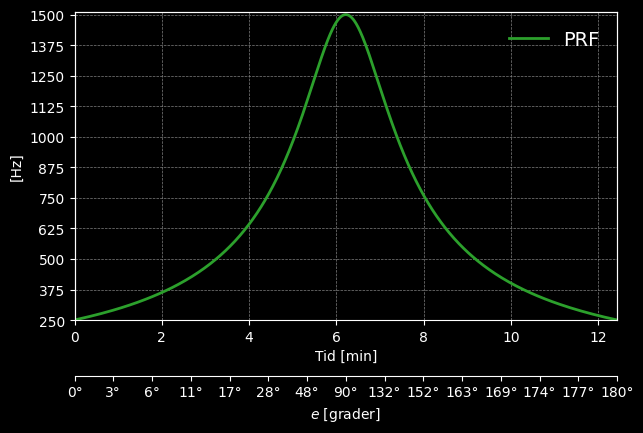

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
plt.style.use('dark_background')

h = 100e3 # km
R_moon = 1737.4e3 # km
a = R_moon + h

m_moon = 7.34767309e22 # kg
G = 6.67430e-11 # m^3 kg^-1 s^-2
T_orbital = 2 * np.pi * np.sqrt((a)**3 / (G * m_moon)) # s
v_orbital = 2 * np.pi * a / T_orbital # m/s

psi_deg = np.linspace(90, 270, 1000) # degrees
psi = np.deg2rad(psi_deg) # rad

theta = np.asin((R_moon/a) * np.sin(psi)) # rad
phi = np.pi - psi - theta

R_sat_meas = a * (np.sin(phi) / np.sin(psi))
R_sat_meas = R_sat_meas * 1e-3 # km

t = (a * (phi + phi[0]) / v_orbital) / 60  # minutter

SAR_freq = 1.25e9 # Hz
c = 3e8 # m/s
v_rad = v_orbital * np.sin(psi) # m/s
doppler = -(2 * SAR_freq * v_rad / c)  * 1e-3 # kHz

PRF = c / (2*R_sat_meas*1e3) # kHz
 

plt.figure(figsize=(7, 4))
plt.plot(t, PRF, label='PRF', color='tab:green', linewidth=2)
plt.xlabel('Tid [min]')
plt.ylabel('[Hz]')
plt.xlim(min(t), max(t))
plt.ylim(min(PRF),max(PRF)+10)
plt.yticks(np.arange(250, 1500+1, 125))
plt.legend(loc='upper right', fontsize=14, frameon=False)
plt.grid(linewidth=0.5, linestyle='--', color='gray')
ax1 = plt.gca()
# Tredje akse: Psi under tid
ax3 = ax1.twiny()  # Lager en ekstra x-akse på toppen
ax3.set_xlim(ax1.get_xlim())

e_interp = interp1d(t, psi_deg[::-1]-90, kind='linear', fill_value='extrapolate')
t_ticks = np.linspace(min(t), max(t), 15)
e_ticks = e_interp(t_ticks)

ax3.set_xticks(t_ticks)
ax3.set_xticklabels([f"{e:.0f}°" for e in e_ticks])
ax3.set_xlabel(r'$e$ [grader]')
ax3.xaxis.set_label_position('bottom')
ax3.xaxis.tick_bottom()
ax3.spines['bottom'].set_position(('outward', 40)) # Flytt psi-aksen ned
ax3.spines['bottom'].set_color('white')
ax3.tick_params(axis='x', colors='white')
plt.savefig('Figurer/PRF.pdf', bbox_inches='tight')
plt.show()

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
plt.style.use('dark_background')

h = 100e3 # km
R_moon = 1737.4e3 # km
a = R_moon + h

m_moon = 7.34767309e22 # kg
G = 6.67430e-11 # m^3 kg^-1 s^-2
T_orbital = 2 * np.pi * np.sqrt((a)**3 / (G * m_moon)) # s
v_orbital = 2 * np.pi * a / T_orbital # m/s

# Caluclate average PRF based on the start elevation angle
d_L = 0.5
beta_krater = np.atan(d_L) # degrees
beta = np.linspace(beta_krater,np.pi-beta_krater,1000) # rad
psi = np.pi/2+beta # rad

theta = np.asin((R_moon/a) * np.sin(psi)) # rad
phi = np.pi - psi - theta

R_sat_meas = a * (np.sin(phi) / np.sin(psi))
R_sat_meas = R_sat_meas * 1e-3 # km

t = (a * (phi + phi[0]) / v_orbital) / 60  # minutter

SAR_freq = 1.25e9 # Hz
c = 3e8 # m/s
v_rad = v_orbital * np.sin(psi) # m/s
doppler = -(2 * SAR_freq * v_rad / c)  * 1e-3 # kHz

PRF = c / (2*R_sat_meas*1e3) # kHz

print(f"Synlighetsperiode: {t[0]:.2f} min")
print(f"AVG PRF: {np.mean(PRF):.2f} Hz")
print(f"AVG Sat avstand: {np.mean(R_sat_meas):.2f} km")
print(f"Max doppler: {np.max(doppler):.2f} kHz")


Synlighetsperiode: 3.72 min
AVG PRF: 1230.71 Hz
AVG Sat avstand: 127.12 km
Max doppler: 12.18 kHz
